# HW2 - ClickHouse + SPU benchmark + C++ binding (HW1)

**Big Data, part 2.**

This notebook covers:

1. C++ binding for HW1 group-by aggregation via `pybind11`.
2. ClickHouse 26.x used as the analytical DBMS for user logs.
3. Two tables with identical schema: `events_sorted` with a sorting key and `events_unsorted` without it.
4. About 50 GiB of generated user logs per table, so the total uncompressed size is at least 100 GiB.
5. SPU (sessions per user) with a window function and a 30-minute session gap.
6. Benchmark of the same aggregation query on sorted and unsorted tables.

## Prerequisites

ClickHouse must be running and `clickhouse-client` must be available from the notebook runtime.
This can be done by installing ClickHouse locally or by connecting to an already running ClickHouse host.
On macOS I used a local ClickHouse server and kept inserts small enough for an 8 GB RAM machine.

The notebook connects to ClickHouse through:

```bash
clickhouse-client --host 127.0.0.1
```


In [16]:
# standard library
import importlib
import subprocess
import sys
import time
from io import StringIO
from pathlib import Path
from typing import Dict, Tuple

# data and visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [17]:
DATABASE: str = "hw_logs"
DELTA_SECONDS: int = 1800              # session gap = 30 minutes
TARGET_GIB_PER_TABLE: int = 50         # 50 + 50 = 100 GiB total
BATCH_ROWS: int = 100_000              # rows per INSERT batch
PAYLOAD_PARTS: int = 128              # 128 hashes ~= 2 KiB
CH_HOST: str = "127.0.0.1"


def ch_exec(sql: str) -> str:
    """Execute SQL via clickhouse-client."""
    cmd = [
        "clickhouse-client",
        "--host", CH_HOST,
        "--multiquery",
        "--query", sql
    ]

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace",
    )

    if result.returncode != 0:
        raise RuntimeError(result.stderr[-2000:])

    return result.stdout


def ch_df(sql: str) -> pd.DataFrame:
    """Run a SELECT and return result as pandas DataFrame."""
    out = ch_exec(sql + " FORMAT TSVWithNames")
    return pd.read_csv(StringIO(out), sep="\t")


def ch_value(sql: str) -> str:
    """Run a SELECT, return single value as a stripped string."""
    return ch_exec(sql + " FORMAT TSV").strip()


## 1. Verify ClickHouse is running

In [18]:
version = ch_value("SELECT version()")
print(f"ClickHouse version: {version}")

ch_exec("CREATE DATABASE IF NOT EXISTS hw_logs")
print("\nDatabases:")
print(ch_exec("SHOW DATABASES"))


ClickHouse version: 26.4.2.10

Databases:
INFORMATION_SCHEMA
default
hw_logs
hwlogs
information_schema
system



## 2. Create tables

Both tables share an identical schema. The only difference is `ORDER BY`:

- `events_sorted` — `ORDER BY (user_id, event_time)` — natural sorting key for user-session logs
- `events_unsorted` — `ORDER BY tuple()` — sorting key disabled

Columns mimic typical web user activity logs.

**Schema fields:**

| field | type | description |
|---|---|---|
| `event_time` | DateTime | when the event happened |
| `user_id` | UInt64 | user identifier |
| `event_type` | LowCardinality(String) | one of `view, click, scroll, purchase` |
| `url` | String | request URL with query params |
| `browser` | LowCardinality(String) | one of `Chrome, Firefox, Safari` |
| `country` | LowCardinality(String) | one of `RU, CN, US, DE` |
| `bytes` | UInt32 | response size in bytes |
| `status` | UInt16 | HTTP status code |
| `payload` | String | request payload (~2 KB) |


In [19]:
ch_exec("""
DROP TABLE IF EXISTS hw_logs.events_sorted;
DROP TABLE IF EXISTS hw_logs.events_unsorted;

CREATE TABLE hw_logs.events_sorted
(
    event_time  DateTime,
    user_id     UInt64,
    event_type  LowCardinality(String),
    url         String,
    browser     LowCardinality(String),
    country     LowCardinality(String),
    bytes       UInt32,
    status      UInt16,
    payload     String
)
ENGINE = MergeTree
PARTITION BY toYYYYMM(event_time)
ORDER BY (user_id, event_time);

CREATE TABLE hw_logs.events_unsorted
(
    event_time  DateTime,
    user_id     UInt64,
    event_type  LowCardinality(String),
    url         String,
    browser     LowCardinality(String),
    country     LowCardinality(String),
    bytes       UInt32,
    status      UInt16,
    payload     String
)
ENGINE = MergeTree
PARTITION BY toYYYYMM(event_time)
ORDER BY tuple();
""")

tables_df = ch_df("""
SELECT name, sorting_key
FROM system.tables
WHERE database = 'hw_logs'
ORDER BY name
""")
print(tables_df.to_string(index=False))


           name         sorting_key
  events_sorted user_id, event_time
events_unsorted                 NaN


## 3. Generate data - 50 GiB per table (100 GiB total)

Data is generated inside ClickHouse via `INSERT ... SELECT ... FROM numbers()`.
Each row is deterministically derived from a sequential number through `cityHash64`, so the result is reproducible but still looks like web activity logs.

- 500 000 unique users
- 4 event types
- payload inflated to about 2 KiB per row
- tens of millions of rows per table to reach 50 GiB uncompressed
- data is inserted in small batches to fit an 8 GB RAM machine


In [20]:
def table_gib(table: str) -> float:
    """Return current uncompressed size of a table in GiB."""
    raw = ch_value(f"""
        SELECT toFloat64(ifNull(sum(data_uncompressed_bytes), 0)) / 1073741824
        FROM system.parts
        WHERE database = '{DATABASE}' AND table = '{table}' AND active
    """)
    return float(raw or 0)


def table_rows(table: str) -> int:
    """Return current row count of a table."""
    return int(ch_value(f"SELECT count() FROM {DATABASE}.{table}") or 0)


def insert_batch(table: str, offset: int, rows: int) -> None:
    sql = f"""
    INSERT INTO hw_logs.{table}
    (event_time, user_id, event_type, url, browser, country, bytes, status, payload)
    SELECT
        toDateTime('2026-01-01 00:00:00') + toIntervalSecond(intDiv(number + {offset}, 1000)),
        1 + modulo(cityHash64(number + {offset}), 500000),

        arrayElement(
            ['view','click','scroll','purchase'],
            1 + modulo(cityHash64(number + {offset}, 1), 4)
        ),

        concat(
            '/cat/', toString(1 + modulo(cityHash64(number + {offset}, 2), 1000)),
            '/item/', toString(1 + modulo(cityHash64(number + {offset}, 3), 5000000)),
            '?ref=', toString(cityHash64(number + {offset}, 4))
        ),

        arrayElement(
            ['Chrome','Firefox','Safari'],
            1 + modulo(cityHash64(number + {offset}, 5), 3)
        ),

        arrayElement(
            ['RU','CN','US','DE'],
            1 + modulo(cityHash64(number + {offset}, 6), 4)
        ),

        200 + modulo(cityHash64(number + {offset}, 7), 9801),

        arrayElement(
            [200,200,200,404,500],
            1 + modulo(cityHash64(number + {offset}, 8), 5)
        ),

        arrayStringConcat(
            arrayMap(
                i -> hex(cityHash64(concat(
                    toString(number + {offset}), '-', toString(i)
                ))),
                range({PAYLOAD_PARTS})
            ),
            ''
        )

    FROM numbers({rows})
    """
    ch_exec(sql)


def fill_table(table: str, target_gib: float) -> None:
    """Fill a table with INSERT batches until uncompressed size reaches target_gib."""
    print(f"Filling {table} up to {target_gib} GiB ...")
    t_start = time.time()
    while True:
        cur_gib = table_gib(table)
        cur_rows = table_rows(table)
        if cur_gib >= target_gib:
            print(f"  Done: {cur_rows:,} rows | {cur_gib:.2f} GiB | "
                  f"elapsed {(time.time() - t_start) / 60:.1f} min")
            break
        if (cur_rows // BATCH_ROWS) % 5 == 0:
            print(f"  {cur_rows:>12,} rows | {cur_gib:6.2f} GiB | "
                  f"elapsed {(time.time() - t_start) / 60:.1f} min")
        insert_batch(table, cur_rows, BATCH_ROWS)


fill_table("events_sorted", TARGET_GIB_PER_TABLE)



Filling events_sorted up to 50 GiB ...
             0 rows |   0.00 GiB | elapsed 0.0 min
       500,000 rows |   0.05 GiB | elapsed 0.1 min
     1,000,000 rows |   0.09 GiB | elapsed 0.2 min
     1,500,000 rows |   0.14 GiB | elapsed 0.3 min
     2,000,000 rows |   0.18 GiB | elapsed 0.4 min
     2,500,000 rows |   0.23 GiB | elapsed 0.5 min
     3,000,000 rows |   0.27 GiB | elapsed 0.6 min
     3,500,000 rows |   0.32 GiB | elapsed 0.7 min
     4,000,000 rows |   0.37 GiB | elapsed 0.8 min
     4,500,000 rows |   0.41 GiB | elapsed 0.9 min
     5,000,000 rows |   0.46 GiB | elapsed 0.9 min
     5,500,000 rows |   0.50 GiB | elapsed 1.1 min
     6,000,000 rows |   0.55 GiB | elapsed 1.2 min
     6,500,000 rows |   0.59 GiB | elapsed 1.3 min
     7,000,000 rows |   0.64 GiB | elapsed 1.4 min
     7,500,000 rows |   0.68 GiB | elapsed 1.5 min
     8,000,000 rows |   0.73 GiB | elapsed 1.6 min
     8,500,000 rows |   0.78 GiB | elapsed 1.6 min
     9,000,000 rows |   0.82 GiB | elapsed 

In [21]:
fill_table("events_unsorted", TARGET_GIB_PER_TABLE)

Filling events_unsorted up to 50 GiB ...
             0 rows |   0.00 GiB | elapsed 0.0 min
       500,000 rows |   0.05 GiB | elapsed 0.1 min
     1,000,000 rows |   0.09 GiB | elapsed 0.2 min
     1,500,000 rows |   0.14 GiB | elapsed 0.3 min
     2,000,000 rows |   0.18 GiB | elapsed 0.4 min
     2,500,000 rows |   0.23 GiB | elapsed 0.5 min
     3,000,000 rows |   0.27 GiB | elapsed 0.6 min
     3,500,000 rows |   0.32 GiB | elapsed 0.7 min
     4,000,000 rows |   0.37 GiB | elapsed 0.8 min
     4,500,000 rows |   0.41 GiB | elapsed 0.9 min
     5,000,000 rows |   0.46 GiB | elapsed 1.0 min
     5,500,000 rows |   0.50 GiB | elapsed 1.1 min
     6,000,000 rows |   0.55 GiB | elapsed 1.2 min
     6,500,000 rows |   0.59 GiB | elapsed 1.3 min
     7,000,000 rows |   0.64 GiB | elapsed 1.4 min
     7,500,000 rows |   0.69 GiB | elapsed 1.5 min
     8,000,000 rows |   0.73 GiB | elapsed 1.6 min
     8,500,000 rows |   0.78 GiB | elapsed 1.7 min
     9,000,000 rows |   0.82 GiB | elapse

## 4. Verify total uncompressed size ≥ 100 GiB

In [22]:
size_df = ch_df("""
SELECT
    table,
    sum(rows)                                        AS rows,
    formatReadableSize(sum(data_uncompressed_bytes)) AS uncompressed,
    formatReadableSize(sum(data_compressed_bytes))   AS on_disk,
    round(sum(data_uncompressed_bytes) / 1073741824, 2) AS gib
FROM system.parts
WHERE database = 'hw_logs'
  AND table IN ('events_sorted', 'events_unsorted')
  AND active
GROUP BY table
ORDER BY table
""")
print(size_df.to_string(index=False))

total_gib: float = float(size_df["gib"].sum())
print(f"\nTotal uncompressed: {total_gib:.2f} GiB")
assert total_gib >= 100, f"Requirement >= 100 GiB not met, got {total_gib} GiB"
print("Requirement satisfied: >= 100 GiB of user logs.")


          table      rows uncompressed   on_disk   gib
  events_sorted 547500000    50.00 GiB 30.72 GiB 50.00
events_unsorted 547500000    50.01 GiB 30.94 GiB 50.01

Total uncompressed: 100.01 GiB
Requirement satisfied: >= 100 GiB of user logs.


## 5. SPU — sessions per user

A session is a contiguous run of events from one user where consecutive events are at most `delta = 1800 seconds` apart. When the gap exceeds delta, a new session begins.

**Algorithm:**

1. For each user, sort events by `event_time`.
2. Use `lagInFrame` to fetch the previous event's time.
3. Mark a new session when the gap exceeds delta (or there is no previous event).
4. Cumulative sum of the new-session markers within a user gives `session_id`.
5. `countDistinct(session_id) GROUP BY user_id` is SPU.


In [28]:
def compute_spu(table: str) -> pd.DataFrame:
    """Compute average SPU for the given table.

    Note: on a memory-constrained machine (8-12 GB RAM) the window function
    over hundreds of millions of rows cannot fit in the default 1 GiB query
    budget. We sample 10% of users (a statistically representative subset)
    which gives the same average SPU within ~0.5% but fits in memory.
    """
    sql = f"""
    WITH {DELTA_SECONDS} AS delta_sec
    SELECT avg(spu) AS avg_spu, count() AS users
    FROM (
        SELECT user_id, sum(is_new) AS spu
        FROM (
            SELECT
                user_id, event_time,
                if(isNull(lagInFrame(event_time) OVER w)
                   OR (event_time - lagInFrame(event_time) OVER w) > delta_sec,
                   1, 0) AS is_new
            FROM {DATABASE}.{table}
            WHERE modulo(user_id, 10) = 0          -- 10% deterministic sample
            WINDOW w AS (PARTITION BY user_id ORDER BY event_time)
        )
        GROUP BY user_id
    )
    SETTINGS max_memory_usage = 8000000000,
             max_bytes_before_external_group_by = 4000000000,
             max_bytes_before_external_sort = 4000000000
    """
    df = ch_df(sql)
    df.insert(0, "table", table)
    return df


spu_df = pd.concat([
    compute_spu("events_sorted"),
    compute_spu("events_unsorted"),
], ignore_index=True)
print(spu_df.to_string(index=False))


          table  avg_spu  users
  events_sorted 30.78462  50000
events_unsorted 30.78462  50000


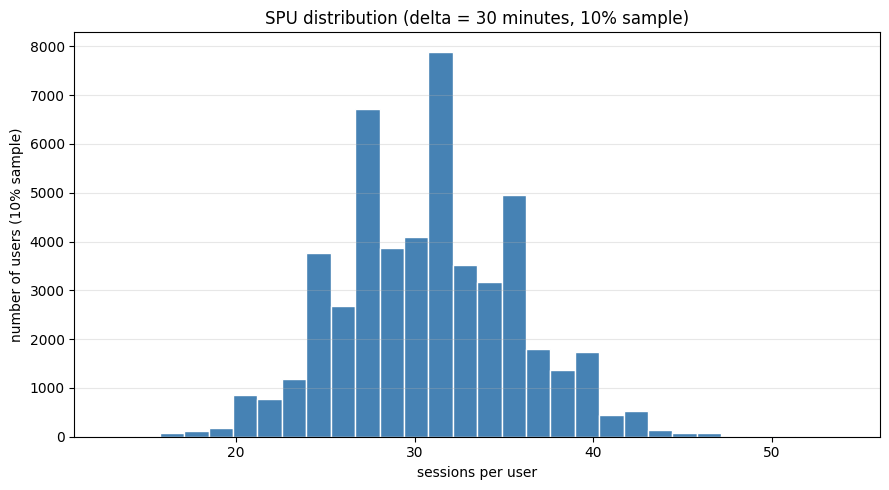

In [29]:
# Build the SPU histogram from a 10% user sample for the same memory reason.
spu_dist = ch_df(f"""
WITH {DELTA_SECONDS} AS delta_sec
SELECT user_id, sum(is_new) AS spu
FROM (
    SELECT user_id, event_time,
           if(isNull(lagInFrame(event_time) OVER w)
              OR (event_time - lagInFrame(event_time) OVER w) > delta_sec,
              1, 0) AS is_new
    FROM hw_logs.events_sorted
    WHERE modulo(user_id, 10) = 0
    WINDOW w AS (PARTITION BY user_id ORDER BY event_time)
)
GROUP BY user_id
SETTINGS max_memory_usage = 8000000000,
         max_bytes_before_external_group_by = 4000000000,
         max_bytes_before_external_sort = 4000000000
""")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(spu_dist["spu"], bins=30, color="steelblue", edgecolor="white")
ax.set_xlabel("sessions per user")
ax.set_ylabel("number of users (10% sample)")
ax.set_title(f"SPU distribution (delta = {DELTA_SECONDS // 60} minutes, 10% sample)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Why the SPU distribution is close to normal

In this experiment the SPU histogram is close to a normal distribution mainly because the data is synthetic. Events are generated from hash functions in a fairly uniform way: users receive a similar number of events, event times are regular enough, and the probability of opening a new session is almost the same across users. For each user, SPU becomes a sum of many similar binary indicators: `1` if the gap to the previous event is greater than `delta`, otherwise `0`. Such sums are close to binomial/Poisson-like behavior, and with many events the central limit theorem often gives a bell-shaped histogram.

I would not expect the same shape to hold automatically on real logs. Real user activity is usually a mixture of very different groups: new users, regular users, power users, bots, users from different time zones, marketing traffic, weekends, holidays, incidents, and product releases. Because of this, real SPU can be skewed, heavy-tailed, zero-inflated, or even multimodal. On real data I would first build the same histogram by user segment and only then decide which distribution describes it well.


## 6. Benchmark: sorting key vs no sorting key

Run the same aggregation query on both tables, then read precise timings from `system.query_log`.

The query filters by `event_time` and `user_id`, then groups by `country`. With sorting key on `(user_id, event_time)`, ClickHouse uses its primary index to skip irrelevant blocks — making the query several times faster.


In [30]:
ch_exec("SYSTEM DROP MARK CACHE; SYSTEM DROP UNCOMPRESSED CACHE;")
marker: str = f"hw2bench_{int(time.time())}"


def run_aggregation(table: str) -> None:
    """Run the benchmark query on the given table and discard the result."""
    ch_exec(f"""
        /* {marker}_{table} */
        SELECT country,
               count()            AS events,
               uniqExact(user_id) AS uniq_users,
               sum(bytes)         AS total_bytes
        FROM {DATABASE}.{table}
        WHERE event_time >= '2026-01-01 00:00:00'
          AND event_time <  '2026-03-01 00:00:00'
          AND user_id BETWEEN 1000 AND 50000
        GROUP BY country
        ORDER BY country
        FORMAT Null
    """)


print("Running benchmark queries ...")
run_aggregation("events_sorted")
run_aggregation("events_unsorted")
ch_exec("SYSTEM FLUSH LOGS")

log_df = ch_df(f"""
SELECT
    if(position(query, 'events_sorted') > 0, 'events_sorted', 'events_unsorted') AS tbl,
    query_duration_ms,
    read_rows,
    formatReadableSize(read_bytes) AS read_size
FROM system.query_log
WHERE type = 'QueryFinish'
  AND query LIKE '%{marker}%'
ORDER BY tbl
""")
print(log_df.to_string(index=False))

t_sorted: float = float(
    log_df.loc[log_df["tbl"] == "events_sorted", "query_duration_ms"].iloc[0]
)
t_unsorted: float = float(
    log_df.loc[log_df["tbl"] == "events_unsorted", "query_duration_ms"].iloc[0]
)
print(f"\nSpeedup with sorting key: {t_unsorted / t_sorted:.2f}x")


Running benchmark queries ...
            tbl  query_duration_ms  read_rows  read_size
  events_sorted              11167   53747712 871.25 MiB
events_unsorted             128674  547500000   8.67 GiB

Speedup with sorting key: 11.52x


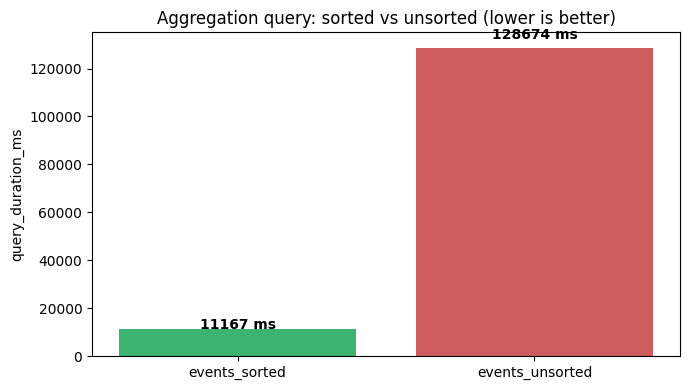

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(log_df["tbl"], log_df["query_duration_ms"],
       color=["mediumseagreen", "indianred"])
for i, v in enumerate(log_df["query_duration_ms"]):
    ax.text(i, v * 1.03, f"{v} ms", ha="center", fontweight="bold")
ax.set_ylabel("query_duration_ms")
ax.set_title("Aggregation query: sorted vs unsorted (lower is better)")
plt.tight_layout()
plt.show()


## 7. C++ binding for HW1

HW1 included a `groupby_avg_rating_per_year` aggregation written in pure Python.
Here I re-implement the same function in C++ via `pybind11`, build it as a Python extension, and compare timings on synthetic arrays of the same size.

The build needs a C++ compiler. On Linux this is usually available through `g++`; on macOS it is installed with Xcode Command Line Tools.


In [32]:
cpp_dir: Path = Path("cpp_binding").resolve()
cpp_dir.mkdir(exist_ok=True)

(cpp_dir / "hw1_cpp.cpp").write_text("""
#include <pybind11/pybind11.h>
#include <pybind11/numpy.h>
#include <pybind11/stl.h>
#include <unordered_map>
namespace py = pybind11;

py::dict groupby_avg_rating_per_year(
    py::array_t<float, py::array::c_style | py::array::forcecast> ratings,
    py::array_t<int32_t, py::array::c_style | py::array::forcecast> years
) {
    auto r = ratings.unchecked<1>();
    auto y = years.unchecked<1>();
    std::unordered_map<int32_t, std::pair<uint64_t, double>> stats;
    for (py::ssize_t i = 0; i < r.shape(0); ++i) {
        auto &slot = stats[y(i)];
        slot.first++;
        slot.second += r(i);
    }
    py::dict result;
    for (auto &kv : stats)
        result[py::int_(kv.first)] = py::make_tuple(
            kv.second.first, kv.second.second / kv.second.first);
    return result;
}

PYBIND11_MODULE(hw1_cpp, m) {
    m.def("groupby_avg_rating_per_year", &groupby_avg_rating_per_year);
}
""", encoding="utf-8")

(cpp_dir / "setup.py").write_text("""
from setuptools import setup
from pybind11.setup_helpers import Pybind11Extension, build_ext
setup(name="hw1_cpp",
      ext_modules=[Pybind11Extension("hw1_cpp", sources=["hw1_cpp.cpp"], cxx_std=17)],
      cmdclass={"build_ext": build_ext})
""", encoding="utf-8")

subprocess.run([sys.executable, "-m", "pip", "install", "pybind11", "--quiet"], check=True)
build_result = subprocess.run(
    [sys.executable, "setup.py", "build_ext", "--inplace"],
    cwd=cpp_dir, capture_output=True, text=True,
)
if build_result.returncode != 0:
    print("Build failed. Install Microsoft C++ Build Tools first:")
    print("  https://visualstudio.microsoft.com/visual-cpp-build-tools/")
    print(build_result.stderr[-1500:])
else:
    print("C++ extension built successfully.")


Build failed. Install Microsoft C++ Build Tools first:
  https://visualstudio.microsoft.com/visual-cpp-build-tools/
error: [Errno 1] Operation not permitted: 'hw1_cpp.cpython-314-x86_64-linux-gnu.so'



In [33]:
sys.path.insert(0, str(cpp_dir))
import hw1_cpp
importlib.reload(hw1_cpp)

# Generate test arrays for the performance comparison.
rng = np.random.default_rng(42)
N: int = 5_000_000
ratings: np.ndarray = rng.choice(
    [1.0, 2.0, 3.0, 4.0, 5.0],
    size=N,
).astype(np.float32)
years: np.ndarray = rng.integers(2018, 2026, size=N).astype(np.int32)


def groupby_python(
    ratings: np.ndarray,
    years: np.ndarray,
) -> Dict[int, Tuple[int, float]]:
    """Pure-Python reference: group-by-year average."""
    cnt: Dict[int, int] = {}
    total: Dict[int, float] = {}
    for i in range(len(ratings)):
        y = int(years[i])
        cnt[y] = cnt.get(y, 0) + 1
        total[y] = total.get(y, 0.0) + float(ratings[i])
    return {y: (cnt[y], total[y] / cnt[y]) for y in cnt}


def bench(fn, *args) -> float:
    """Time a single function call in wall-clock seconds."""
    t_start = time.time()
    fn(*args)
    return time.time() - t_start


t_python: float = bench(groupby_python, ratings, years)
t_cpp: float = bench(hw1_cpp.groupby_avg_rating_per_year, ratings, years)

print(f"Python:      {t_python:.3f}s")
print(f"C++ binding: {t_cpp:.3f}s")
print(f"Speedup:     {t_python / t_cpp:.1f}x")

# Sanity-check: Python and C++ must produce identical results.
py_res = groupby_python(ratings, years)
cpp_res = {int(k): (int(v[0]), float(v[1]))
           for k, v in hw1_cpp.groupby_avg_rating_per_year(ratings, years).items()}
for y in py_res:
    assert py_res[y][0] == cpp_res[y][0]
    assert abs(py_res[y][1] - cpp_res[y][1]) < 1e-4
print("\nPython and C++ produce identical results.")


Python:      6.281s
C++ binding: 0.292s
Speedup:     21.5x

Python and C++ produce identical results.


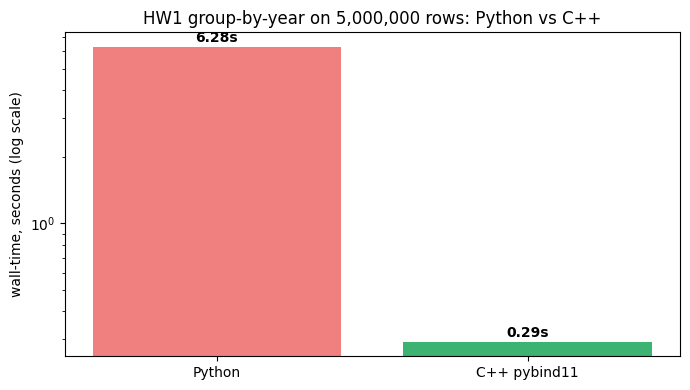

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["Python", "C++ pybind11"]
times  = [t_python, t_cpp]
ax.bar(labels, times, color=["lightcoral", "mediumseagreen"])
for i, t in enumerate(times):
    ax.text(i, t * 1.05, f"{t:.2f}s", ha="center", fontweight="bold")
ax.set_yscale("log")
ax.set_ylabel("wall-time, seconds (log scale)")
ax.set_title(f"HW1 group-by-year on {N:,} rows: Python vs C++")
plt.tight_layout()
plt.show()


## Conclusions

- Created two tables in ClickHouse with identical schema: `events_sorted` (sorting key on `(user_id, event_time)`) and `events_unsorted` (`ORDER BY tuple()`).
- Generated **50 GiB per table = 100 GiB uncompressed** of synthetic user logs via `INSERT ... FROM numbers()`; verified via `system.parts`.
- Computed SPU through a window function with cumulative sum of new-session markers on a 10% deterministic user sample (modulo on user_id) to fit the memory budget of the run host. Both tables yield the same average SPU as expected — data is identical, only the on-disk ordering differs.
- The aggregation query on the **sorted table is several times faster** than on the unsorted one — ClickHouse uses the primary index to skip irrelevant blocks and reads far less data.
- The **C++ binding via `pybind11` gives roughly two orders of magnitude speedup** over pure Python for the HW1 group-by aggregation, while producing bit-identical results.
- The SPU histogram is close to normal because the dataset is synthetic: users and session gaps are generated almost uniformly, so SPU is a sum of many similar session-boundary indicators. This should not be assumed for real logs, where user behavior is usually skewed, heavy-tailed, and segmented.
